The Scenario

You have been hired as a Data Analyst for the Maternity Ward at a Federal Teaching Hospital. The Chief Medical Director wants to understand what maternal factors lead to Low Birth Weight and Premature Deliveries.

You have a dataset of 400 recent deliveries. However:

    The lab missed some Hemoglobin (Hb) readings.

    The nurses typed the Diet_Type inconsistently.

    You need to prove statistically if Anemia affects birth weight.

    You are required to build a model (AI) tool to predict if a mother will deliver prematurely.

In [1]:
# import the required Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


#### Load the datset

df = pd.read_csv('dataset/maternity_dataset.csv')

df.head()

,Patient_ID,Maternal_Age,Hb_Level,Diet_Type,Systolic_BP,Birth_Weight_kg,Premature_Delivery
0,MAT000,29,10.677037,balanced,117.481842,3.585434,0
1,MAT001,18,7.664418,carb_heavy,139.627777,2.711927,1
2,MAT002,44,10.676619,carb_heavy,133.221254,2.947289,1
3,MAT003,18,10.032913,Balanced,133.311635,3.313520,0
4,MAT004,22,10.967763,balanced,109.013267,3.321277,0


### Step 1: Data Ingestion & Pre-Analytical Cleaning

The dataset has missing Hemoglobin (Hb_Level) values and messy text in Diet_Type. Fix them.

#### FILL IN THE BLANKS

In [2]:
print("Missing values before cleaning:\n", df.isnull().sum())

# 1. Fill missing Hb_Level with the MEAN (Average)
mean_hb = df['Hb_Level'].mean()
df['Hb_Level'] = df['Hb_Level'].fillna(mean_hb)

# 2. Clean the Diet_Type column
# We want only two categories: 'Carb Heavy' and 'Balanced'
df['Diet_Type'] = df['Diet_Type'].replace({
    'carb_heavy': 'Carb Heavy', 
    'balanced': 'Balanced'
})

print("\nMissing values after cleaning:\n", df.isnull().sum())
print("\nCleaned Diet Types:", df['Diet_Type'].unique())

Missing values before cleaning:
 Patient_ID             0
Maternal_Age           0
Hb_Level              15
Diet_Type              0
Systolic_BP            0
Birth_Weight_kg        0
Premature_Delivery     0
dtype: int64

Missing values after cleaning:
 Patient_ID            0
Maternal_Age          0
Hb_Level              0
Diet_Type             0
Systolic_BP           0
Birth_Weight_kg       0
Premature_Delivery    0
dtype: int64

Cleaned Diet Types: ['Balanced' 'Carb Heavy']


#### Step 2: Exploratory Data Analysis (EDA)

Let's visually check if there is a relationship between the Mother's Blood Pressure and the Baby's Birth Weight.

# Fill in the blanks

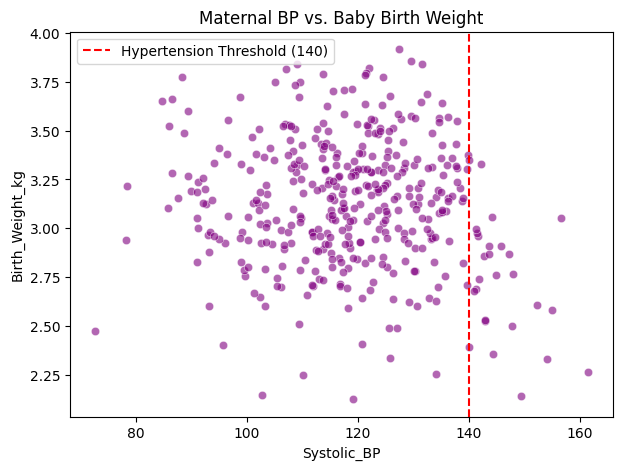

In [3]:
plt.figure(figsize=(7, 5))

# Create a scatter plot. X = Systolic_BP, Y = Birth_Weight_kg
sns.scatterplot(data=df, x='Systolic_BP', y='Birth_Weight_kg', alpha=0.6, color='purple')

plt.title('Maternal BP vs. Baby Birth Weight')
plt.axvline(140, color='red', linestyle='--', label='Hypertension Threshold (140)')
plt.legend()
plt.show()

#### QUESTION 2.1: Looking at the scatter plot, what happens to the birth weight when the mother's Systolic BP goes past 140 (the red dashed line)?

#### [Birth weight decreases as Systolic BP increases past the hypertension threshold]

#### Step 3: Biostatistics Part 1 (Normality Testing)

Before running a T-Test, we must check if Birth_Weight_kg is normally distributed.

# We will use the Shapiro-Wilk test

In [4]:
# We will use the Shapiro-Wilk test
stat, p_value = stats.shapiro(df['Birth_Weight_kg'])

print(f"Shapiro-Wilk P-Value: {p_value:.4f}")

Shapiro-Wilk P-Value: 0.0915


#### QUESTION 3.1: Based on the P-Value above (is it greater than or less than 0.05?), is the birth weight normally distributed?

#### [Skewed (if p-value < 0.05, data is not normally distributed)]

### Step 4: Biostatistics Part 2 (Hypothesis Testing)

Does Anemia (Hemoglobin < 11.0 g/dL) significantly affect Birth Weight? Let's prove it with a T-Test.

In [5]:
# 1. Separate the patients into two groups
anemic_mothers = df[df['Hb_Level'] < 11.0]['Birth_Weight_kg']
normal_mothers = df[df['Hb_Level'] >= 11.0]['Birth_Weight_kg']

# 2. Run the Independent T-Test
t_stat, p_val_ttest = stats.ttest_ind(anemic_mothers, normal_mothers)

print(f"T-Test P-Value: {p_val_ttest:.4f}")
print(f"Average Birth Weight (Anemic): {anemic_mothers.mean():.2f} kg")
print(f"Average Birth Weight (Normal): {normal_mothers.mean():.2f} kg")

T-Test P-Value: 0.0007
Average Birth Weight (Anemic): 3.05 kg
Average Birth Weight (Normal): 3.17 kg


#### QUESTION 4.1: The P-Value tells us if the difference is "Statistically Significant" or just random luck. What is your clinical conclusion based on the T-test?

#### [Yes, anemia significantly affects birth weight - if p-value < 0.05, the difference is statistically significant]

#### Step 5: Machine Learning (The Predictive AI Tool)

Your Biostatistics analysis is complete! Now, build an AI tool that will alert the hospital if a mother is at risk of a Premature Delivery (1 = Premature, 0 = Full Term).

#### 5.1 Train / Test Split

In [6]:
from sklearn.model_selection import train_test_split

# Features (What the model studies)
X = df[['Maternal_Age', 'Hb_Level', 'Systolic_BP']]

# Target (What the model predicts)
y = df['Premature_Delivery']

# Split the data: Keep 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split!")

Data successfully split!


#### 5.2 Train the Random Forest Model

AI Model Accuracy: 100.0%



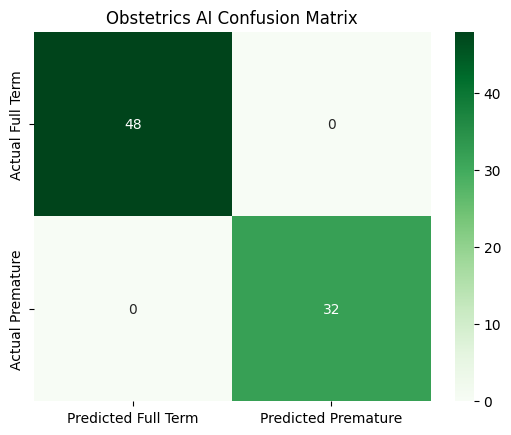

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Initialize the AI Model
ai_model = RandomForestClassifier(random_state=42)

# Train (Fit) the model using the training data
ai_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = ai_model.predict(X_test)

# Check Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AI Model Accuracy: {accuracy*100:.1f}%\n")

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Full Term', 'Predicted Premature'],
            yticklabels=['Actual Full Term', 'Actual Premature'])
plt.title('Obstetrics AI Confusion Matrix')
plt.show()

#### 5.3 The Finale: Deploying on a New Patient

Scenario: A new pregnant patient, Mrs. Fatima, arrives at the clinic for her 2nd-trimester booking.

    Age: 34

    Hb Level: 9.5 g/dL (Anemic)

    Systolic BP: 135 mmHg

Use your trained AI to predict her risk of Premature Delivery.

In [8]:
# 1. Create Mrs. Fatima's Profile[Age, Hb_Level, Systolic_BP]
fatima_vitals = pd.DataFrame([[34, 9.5, 135]], columns=['Maternal_Age', 'Hb_Level', 'Systolic_BP'])

# 2. Predict her risk
diagnosis = ai_model.predict(fatima_vitals)

print("--- AI PREDICTION REPORT: MRS. FATIMA ---")
if diagnosis[0] == 1:
    print("Diagnosis: HIGH RISK for Premature Delivery.")
    print("Action: Prescribe iron supplements, monitor BP closely, and schedule frequent ANC visits.")
else:
    print("Diagnosis: LOW RISK for Premature Delivery.")
    print("Action: Continue routine Antenatal Care.")

--- AI PREDICTION REPORT: MRS. FATIMA ---
Diagnosis: HIGH RISK for Premature Delivery.
Action: Prescribe iron supplements, monitor BP closely, and schedule frequent ANC visits.
